# Task 6: Advanced Analytics + Risk Metrics

## Mission 1: Historical VaR (95%) and CVaR Analysis

### Objective
Calculate Historical Value at Risk (VaR) at the 95% confidence level and Conditional Value at Risk (CVaR) for mutual fund schemes using historical daily NAV returns.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [4]:
nav_df = pd.read_csv("../Data/Raw/02_nav_history.csv")

nav_df.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [5]:
print("Shape:", nav_df.shape)

nav_df.info()

print("\nMissing Values:")
print(nav_df.isnull().sum())

Shape: (46000, 3)
<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 MB

Missing Values:
amfi_code    0
date         0
nav          0
dtype: int64


In [7]:
nav_df["date"] = pd.to_datetime(nav_df["date"])

nav_df = nav_df.sort_values(["amfi_code", "date"])

nav_df.head()

,amfi_code,date,nav
5750,100016,2022-01-03,520.4608
5751,100016,2022-01-04,515.0971
5752,100016,2022-01-05,521.7239
5753,100016,2022-01-06,515.7880
5754,100016,2022-01-07,515.1639


### Calculate Daily Returns

In [8]:
nav_df["daily_return"] = (
    nav_df.groupby("amfi_code")["nav"]
          .pct_change()
)

nav_df.head(10)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


### Calculate Historical VaR (95%)

In [9]:
returns_df = nav_df.dropna(subset=["daily_return"])

var_95 = (
    returns_df.groupby("amfi_code")["daily_return"]
              .quantile(0.05)
              .reset_index()
)

var_95.rename(columns={"daily_return": "VaR_95"}, inplace=True)

var_95.head()

,amfi_code,VaR_95
0,100016,-0.014364
1,100025,-0.003793
2,100033,-0.019034
3,101206,-0.013282
4,101207,-0.026021


### Calculate CVaR (Conditional Value at Risk)

In [10]:
cvar_95 = (
    returns_df.groupby("amfi_code")
    .apply(
        lambda x: x.loc[
            x["daily_return"] <= x["daily_return"].quantile(0.05),
            "daily_return"
        ].mean()
    )
    .reset_index(name="CVaR_95")
)

cvar_95.head()

,amfi_code,CVaR_95
0,100016,-0.018060
1,100025,-0.004994
2,100033,-0.023456
3,101206,-0.017439
4,101207,-0.032459


### Merge VaR and CVaR results


In [13]:
var_cvar_report = pd.merge(var_95, cvar_95, on="amfi_code")

var_cvar_report.head(10)

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459
5,101208,-0.000269,-0.000422
6,102885,-0.012613,-0.015490
7,102886,-0.019220,-0.023251
8,102887,-0.015232,-0.019411
9,118632,-0.013954,-0.017619


### Save the VaR & CVaR report


In [15]:
var_cvar_report.to_csv("../Reports/var_cvar_report.csv", index=False)

print("var_cvar_report.csv saved successfully!")

var_cvar_report.csv saved successfully!


# Mission 2: Rolling 90-Day Sharpe Ratio Analysis

## Objective

Calculate the 90-day Rolling Sharpe Ratio for each mutual fund scheme using daily returns.

The Sharpe Ratio measures the risk-adjusted return of a fund. A higher Sharpe Ratio indicates better performance relative to the amount of risk taken.

The rolling calculation helps analyze how the fund's performance changes over time instead of giving only one overall value.

In [16]:
nav_df["rolling_sharpe"] = (
    nav_df.groupby("amfi_code")["daily_return"]
          .transform(
              lambda x: (
                  x.rolling(window=90).mean()
                  / x.rolling(window=90).std()
              ) * np.sqrt(252)
          )
)

nav_df.head()

,amfi_code,date,nav,daily_return,rolling_sharpe
5750,100016,2022-01-03,520.4608,NaN,NaN
5751,100016,2022-01-04,515.0971,-0.010306,NaN
5752,100016,2022-01-05,521.7239,0.012865,NaN
5753,100016,2022-01-06,515.7880,-0.011377,NaN
5754,100016,2022-01-07,515.1639,-0.001210,NaN


In [17]:
nav_df.dropna(subset=["rolling_sharpe"]).head(10)

,amfi_code,date,nav,daily_return,rolling_sharpe
5840,100016,2022-05-09,516.5793,0.003683,-0.064787
5841,100016,2022-05-10,511.4204,-0.009987,-0.058880
5842,100016,2022-05-11,504.9889,-0.012576,-0.532521
5843,100016,2022-05-12,495.8735,-0.018051,-0.649005
5844,100016,2022-05-13,499.2941,0.006898,-0.498278
5845,100016,2022-05-16,497.1556,-0.004283,-0.419782
5846,100016,2022-05-17,510.4206,0.026682,-0.029988
5847,100016,2022-05-18,506.2251,-0.008220,-0.132298
5848,100016,2022-05-19,502.3871,-0.007582,-0.194050
5849,100016,2022-05-20,500.1462,-0.004461,-0.415433


### Selecting 5 mutual fund schemes


In [18]:
key_funds = nav_df["amfi_code"].unique()[:5]

print("Selected AMFI Codes:")
print(key_funds)

Selected AMFI Codes:
[100016 100025 100033 101206 101207]


### Plotting Rolling Sharpe Ratio for the selected 5 funds

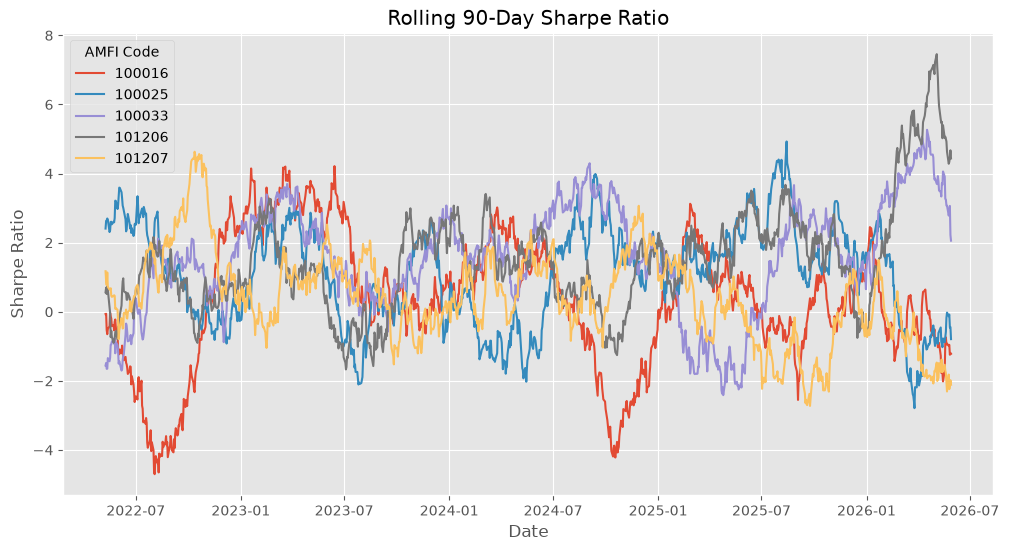

In [20]:
plt.figure(figsize=(12, 6))

for fund in key_funds:
    fund_data = nav_df[nav_df["amfi_code"] == fund]
    plt.plot(
        fund_data["date"],
        fund_data["rolling_sharpe"],
        label=str(fund)
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend(title="AMFI Code")
plt.grid(True)
plt.show()

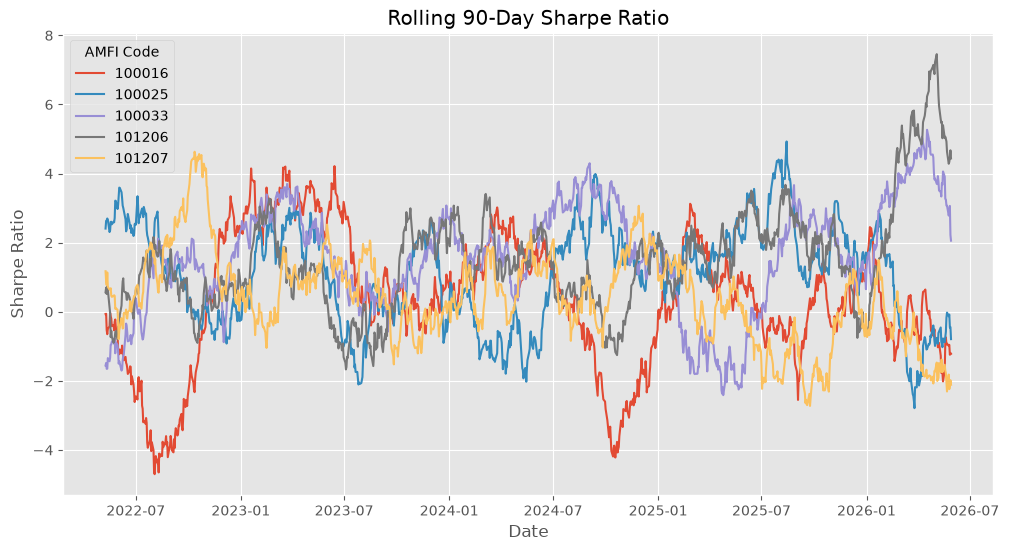

rolling_sharpe_chart.png saved successfully!


In [21]:
plt.figure(figsize=(12, 6))

for fund in key_funds:
    fund_data = nav_df[nav_df["amfi_code"] == fund]
    plt.plot(
        fund_data["date"],
        fund_data["rolling_sharpe"],
        label=str(fund)
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend(title="AMFI Code")
plt.grid(True)

plt.savefig("../Reports/rolling_sharpe_chart.png", dpi=300, bbox_inches="tight")

plt.show()

print("rolling_sharpe_chart.png saved successfully!")

# Mission 3: Investor Cohort Analysis

## Objective

Group investors by the year of their first transaction and analyze:

- Average SIP Amount
- Total Invested Amount
- Most Preferred Mutual Fund

This analysis helps understand investment behaviour of investors who started investing in different years.

###  Loading dataset

In [22]:
investor_df = pd.read_csv("../Data/Raw/08_investor_transactions.csv")

investor_df.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [23]:
print("Shape:", investor_df.shape)

investor_df.info()

print("\nMissing Values:")
print(investor_df.isnull().sum())

Shape: (32778, 13)
<class 'pandas.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   investor_id         32778 non-null  str    
 1   transaction_date    32778 non-null  str    
 2   amfi_code           32778 non-null  int64  
 3   transaction_type    32778 non-null  str    
 4   amount_inr          32778 non-null  int64  
 5   state               32778 non-null  str    
 6   city                32778 non-null  str    
 7   city_tier           32778 non-null  str    
 8   age_group           32778 non-null  str    
 9   gender              32778 non-null  str    
 10  annual_income_lakh  32778 non-null  float64
 11  payment_mode        32778 non-null  str    
 12  kyc_status          32778 non-null  str    
dtypes: float64(1), int64(2), str(10)
memory usage: 3.3 MB

Missing Values:
investor_id           0
transaction_date      0
amfi_code             0


### Convert transaction_date to datetime format

In [24]:
investor_df["transaction_date"] = pd.to_datetime(
    investor_df["transaction_date"]
)

investor_df["transaction_date"].head()

0   2024-01-01
1   2024-01-01
2   2024-01-01
3   2024-01-01
4   2024-01-01
Name: transaction_date, dtype: datetime64[us]

### First transaction date of every investor

In [25]:
first_transaction = (
    investor_df.groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)

first_transaction.head()

,investor_id,transaction_date
0,INV000001,2024-11-04
1,INV000002,2024-03-29
2,INV000003,2024-07-16
3,INV000004,2024-03-16
4,INV000005,2024-04-27


### Extracting first transaction year


In [26]:
first_transaction["cohort_year"] = (
    first_transaction["transaction_date"].dt.year
)

first_transaction.head()

,investor_id,transaction_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [27]:
investor_df = investor_df.merge(
    first_transaction[["investor_id", "cohort_year"]],
    on="investor_id",
    how="left"
)

investor_df.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


### Average SIP amount for each cohort

In [28]:
avg_sip = (
    investor_df[investor_df["transaction_type"] == "SIP"]
    .groupby("cohort_year")["amount_inr"]
    .mean()
    .reset_index(name="avg_sip_amount")
)

avg_sip

,cohort_year,avg_sip_amount
0,2024,10996.885825
1,2025,13505.209581


### Total invested amount for each cohort

In [29]:
total_investment = (
    investor_df
    .groupby("cohort_year")["amount_inr"]
    .sum()
    .reset_index(name="total_invested")
)

total_investment

,cohort_year,total_invested
0,2024,3491125187
1,2025,30455243


### Most preferred mutual fund in each cohort

In [30]:
top_fund = (
    investor_df
    .groupby(["cohort_year", "amfi_code"])
    .size()
    .reset_index(name="transactions")
)

top_fund = (
    top_fund
    .sort_values(
        ["cohort_year", "transactions"],
        ascending=[True, False]
    )
    .drop_duplicates("cohort_year")
)

top_fund

,cohort_year,amfi_code,transactions
35,2024,148568,874
62,2025,119599,12


### Mergeing all cohort metrics

In [31]:
cohort_report = (
    avg_sip
    .merge(total_investment, on="cohort_year")
    .merge(
        top_fund[["cohort_year", "amfi_code"]],
        on="cohort_year"
    )
)

cohort_report.rename(
    columns={"amfi_code": "top_preferred_fund"},
    inplace=True
)

cohort_report

,cohort_year,avg_sip_amount,total_invested,top_preferred_fund
0,2024,10996.885825,3491125187,148568
1,2025,13505.209581,30455243,119599


In [32]:
cohort_report.to_csv(
    "../Reports/investor_cohort_report.csv",
    index=False
)

print("investor_cohort_report.csv saved successfully!")

investor_cohort_report.csv saved successfully!


# Mission 4: SIP Continuity Analysis

## Objective

Analyze SIP investment continuity by identifying investors with at least 6 SIP transactions. Calculate the average gap (in days) between consecutive SIP investments and identify investors with an average gap greater than 35 days as **"At-Risk"**.

This analysis helps identify investors who may have stopped or delayed their SIP investments.

### Loading dataset

In [33]:
investor_df = pd.read_csv("../Data/Raw/08_investor_transactions.csv")

investor_df.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


### Filtering only SIP transactions

In [34]:
sip_df = investor_df[investor_df["transaction_type"] == "SIP"].copy()

sip_df.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified


In [35]:
sip_df["transaction_date"] = pd.to_datetime(sip_df["transaction_date"])

sip_df.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified


In [36]:
sip_df = sip_df.sort_values(["investor_id", "transaction_date"])

sip_df.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified


### Calculating the gap between consecutive SIP transactions


In [37]:
sip_df["gap_days"] = (
    sip_df.groupby("investor_id")["transaction_date"]
          .diff()
          .dt.days
)

sip_df.head(10)

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,gap_days
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,NaN
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,76.0
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,NaN
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,176.0
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,238.0
12652,INV000003,2024-07-16,101207,SIP,2676,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,NaN
27622,INV000003,2025-03-11,149322,SIP,15185,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,238.0
4773,INV000004,2024-03-16,101208,SIP,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,NaN
6418,INV000004,2024-04-11,119095,SIP,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,26.0
8271,INV000004,2024-05-09,120844,SIP,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,28.0


### Counting number of SIP transactions 

In [38]:
sip_counts = (
    sip_df.groupby("investor_id")
          .size()
          .reset_index(name="sip_count")
)

sip_counts.head()

,investor_id,sip_count
0,INV000001,2
1,INV000002,3
2,INV000003,2
3,INV000004,6
4,INV000005,3


### Keeping investors having at least 6 SIP transactions


In [39]:
eligible_investors = sip_counts[sip_counts["sip_count"] >= 6]

eligible_investors.head()

,investor_id,sip_count
3,INV000004,6
7,INV000008,6
9,INV000010,6
10,INV000011,7
11,INV000012,8


### Keeping only eligible investors in the SIP dataset


In [40]:
sip_analysis = sip_df.merge(
    eligible_investors[["investor_id"]],
    on="investor_id",
    how="inner"
)

sip_analysis.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,gap_days
0,INV000004,2024-03-16,101208,SIP,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,NaN
1,INV000004,2024-04-11,119095,SIP,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,26.0
2,INV000004,2024-05-09,120844,SIP,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,28.0
3,INV000004,2024-07-07,148569,SIP,9761,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,59.0
4,INV000004,2025-03-29,149324,SIP,14282,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,265.0


### Calculate average gap between SIP transactions


In [41]:
avg_gap = (
    sip_analysis.groupby("investor_id")["gap_days"]
    .mean()
    .reset_index(name="avg_gap_days")
)

avg_gap.head()

,investor_id,avg_gap_days
0,INV000004,85.400000
1,INV000008,70.400000
2,INV000010,64.800000
3,INV000011,40.166667
4,INV000012,57.000000


### Flaging investors with average gap greater than 35 days


In [42]:
avg_gap["status"] = np.where(
    avg_gap["avg_gap_days"] > 35,
    "At-Risk",
    "Regular"
)

avg_gap.head(10)

,investor_id,avg_gap_days,status
0,INV000004,85.400000,At-Risk
1,INV000008,70.400000,At-Risk
2,INV000010,64.800000,At-Risk
3,INV000011,40.166667,At-Risk
4,INV000012,57.000000,At-Risk
5,INV000013,55.333333,At-Risk
6,INV000014,75.333333,At-Risk
7,INV000023,58.571429,At-Risk
8,INV000028,93.600000,At-Risk
9,INV000029,60.666667,At-Risk


In [43]:
avg_gap.to_csv(
    "../Reports/sip_continuity_report.csv",
    index=False
)

print("sip_continuity_report.csv saved successfully!")

sip_continuity_report.csv saved successfully!


# Mission 5: Simple Fund Recommender

## Objective

Build a simple mutual fund recommendation system based on investor risk appetite.

The recommender classifies funds into Low, Moderate, and High risk categories using their latest Rolling Sharpe Ratio and recommends the Top 3 funds with the highest Sharpe Ratio within the selected risk category.

In [44]:
latest_sharpe = (
    nav_df.dropna(subset=["rolling_sharpe"])
          .sort_values("date")
          .groupby("amfi_code")
          .tail(1)
          [["amfi_code", "rolling_sharpe"]]
          .reset_index(drop=True)
)

latest_sharpe.head()

,amfi_code,rolling_sharpe
0,119551,2.972235
1,149322,-1.058035
2,119093,1.338173
3,119092,-1.715206
4,118636,0.816996


### Assigning risk grade based on latest Sharpe Ratio

In [45]:
latest_sharpe["risk_grade"] = np.select(
    [
        latest_sharpe["rolling_sharpe"] >= 2,
        latest_sharpe["rolling_sharpe"] >= 1,
        latest_sharpe["rolling_sharpe"] < 1
    ],
    [
        "Low",
        "Moderate",
        "High"
    ],
    default="High"
)

latest_sharpe.head(10)

,amfi_code,rolling_sharpe,risk_grade
0,119551,2.972235,Low
1,149322,-1.058035,High
2,119093,1.338173,Moderate
3,119092,-1.715206,High
4,118636,0.816996,High
5,118635,-0.365087,High
6,118634,2.934098,Low
7,118633,1.899712,Moderate
8,118632,2.650524,Low
9,119094,0.739393,High


### Identify Top 3 funds


In [46]:
def recommend_funds(risk_level):

    recommendations = (
        latest_sharpe[
            latest_sharpe["risk_grade"].str.lower() == risk_level.lower()
        ]
        .sort_values("rolling_sharpe", ascending=False)
        .head(3)
    )

    return recommendations

In [47]:
recommend_funds("Low")

,amfi_code,rolling_sharpe,risk_grade
31,120507,14.584282,Low
27,120844,14.144869,Low
12,101208,13.952418,Low


In [48]:
recommend_funds("Moderate")

,amfi_code,rolling_sharpe,risk_grade
7,118633,1.899712,Moderate
32,120506,1.443443,Moderate
11,102885,1.356384,Moderate


In [49]:
recommend_funds("High")

,amfi_code,rolling_sharpe,risk_grade
4,118636,0.816996,High
9,119094,0.739393,High
21,119552,0.610384,High


In [50]:
latest_sharpe.to_csv(
    "../Reports/latest_sharpe_report.csv",
    index=False
)

print("latest_sharpe_report.csv saved successfully!")

latest_sharpe_report.csv saved successfully!


# Mission 6: Sector HHI Concentration Analysis

## Objective

Calculate the Herfindahl-Hirschman Index (HHI) for each mutual fund using portfolio sector weights.

HHI = Σ(weight²)

Higher HHI indicates a more concentrated portfolio, while lower HHI indicates better diversification.

In [53]:
portfolio_df = pd.read_csv("../Data/Raw/09_portfolio_holdings.csv")

portfolio_df.head()



,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


### Converting weight percentage to decimal

In [54]:
portfolio_df["weight"] = portfolio_df["weight_pct"] / 100

portfolio_df.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date,weight
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31,0.1385
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31,0.1119
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31,0.0990
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31,0.0476
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31,0.1025


### Calculate HHI for every mutual fund

In [55]:
hhi_report = (
    portfolio_df
    .groupby("amfi_code")["weight"]
    .apply(lambda x: (x ** 2).sum())
    .reset_index(name="HHI")
)

hhi_report.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


### Classifying the funds

In [56]:
hhi_report["portfolio_type"] = np.where(
    hhi_report["HHI"] >= 0.18,
    "Highly Concentrated",
    np.where(
        hhi_report["HHI"] >= 0.12,
        "Moderately Concentrated",
        "Diversified"
    )
)

hhi_report.head(10)

,amfi_code,HHI,portfolio_type
0,100016,0.139534,Moderately Concentrated
1,100033,0.147592,Moderately Concentrated
2,101206,0.129332,Moderately Concentrated
3,101207,0.200700,Highly Concentrated
4,102885,0.174709,Moderately Concentrated
5,102886,0.114693,Diversified
6,102887,0.129805,Moderately Concentrated
7,118632,0.168298,Moderately Concentrated
8,118633,0.121461,Moderately Concentrated
9,118634,0.108358,Diversified


In [57]:
hhi_report = hhi_report.sort_values(
    by="HHI",
    ascending=False
)

hhi_report.head(10)

,amfi_code,HHI,portfolio_type
11,119092,0.206448,Highly Concentrated
3,101207,0.200700,Highly Concentrated
18,119599,0.174751,Moderately Concentrated
4,102885,0.174709,Moderately Concentrated
7,118632,0.168298,Moderately Concentrated
29,148568,0.167930,Moderately Concentrated
21,120505,0.157570,Moderately Concentrated
22,120506,0.153794,Moderately Concentrated
27,125498,0.152414,Moderately Concentrated
23,120841,0.149680,Moderately Concentrated


In [58]:
hhi_report.to_csv(
    "../Reports/hhi_concentration_report.csv",
    index=False
)

print("hhi_concentration_report.csv saved successfully!")

hhi_concentration_report.csv saved successfully!


# Mission 7: Advanced Insights

## Objective

Summarize key insights obtained from the advanced analytics performed on the mutual fund datasets.

### Insight 1 – Historical VaR & CVaR
Funds with more negative VaR and CVaR values indicate higher downside risk, meaning they are more vulnerable to large losses during unfavorable market conditions.

### Insight 2 – Rolling 90-Day Sharpe Ratio
Funds with consistently higher Rolling Sharpe Ratios demonstrated better risk-adjusted performance over time compared to funds with lower or negative Sharpe Ratios.

### Insight 3 – Investor Cohort Analysis
The investor cohort analysis showed differences in average SIP amount, total investments, and preferred mutual fund schemes across different investor cohorts.

### Insight 4 – SIP Continuity Analysis
Several investors were identified as "At-Risk" because their average SIP gap exceeded 35 days, indicating irregular investment behavior and possible discontinuation of SIPs.

### Insight 5 – Portfolio Concentration (HHI)
Funds with higher HHI values were identified as more concentrated portfolios, whereas lower HHI values represented better diversification across holdings.